In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from narwhals import DataFrame

In [93]:
Data = pd.read_csv("../data/raw_data.csv")
Data

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [94]:
df = pd.DataFrame(Data.drop("smoking_history", axis=1))
df

,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,25.19,6.6,140,0
1,Female,54.0,0,0,27.32,6.6,80,0
2,Male,28.0,0,0,27.32,5.7,158,0
3,Female,36.0,0,0,23.45,5.0,155,0
4,Male,76.0,1,1,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,27.32,6.2,90,0
99996,Female,2.0,0,0,17.37,6.5,100,0
99997,Male,66.0,0,0,27.83,5.7,155,0
99998,Female,24.0,0,0,35.42,4.0,100,0


In [95]:
print(df['gender'].value_counts())

gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64


In [96]:
df = df[df['gender'] != 'Other']

In [97]:
#gender to integer
df = pd.get_dummies(df, columns=['gender'], drop_first=True, dtype=int)


In [98]:
df.describe()


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Male
count,99982.000000,99982.000000,99982.000000,99982.000000,99982.000000,99982.000000,99982.000000,99982.000000
mean,41.888076,0.074863,0.039427,27.320757,5.527529,138.057810,0.085015,0.414375
std,22.517206,0.263172,0.194610,6.636853,1.070665,40.709469,0.278906,0.492616
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000,0.000000
25%,24.000000,0.000000,0.000000,23.630000,4.800000,100.000000,0.000000,0.000000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000,0.000000
75%,60.000000,0.000000,0.000000,29.580000,6.200000,159.000000,0.000000,1.000000
max,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000,1.000000


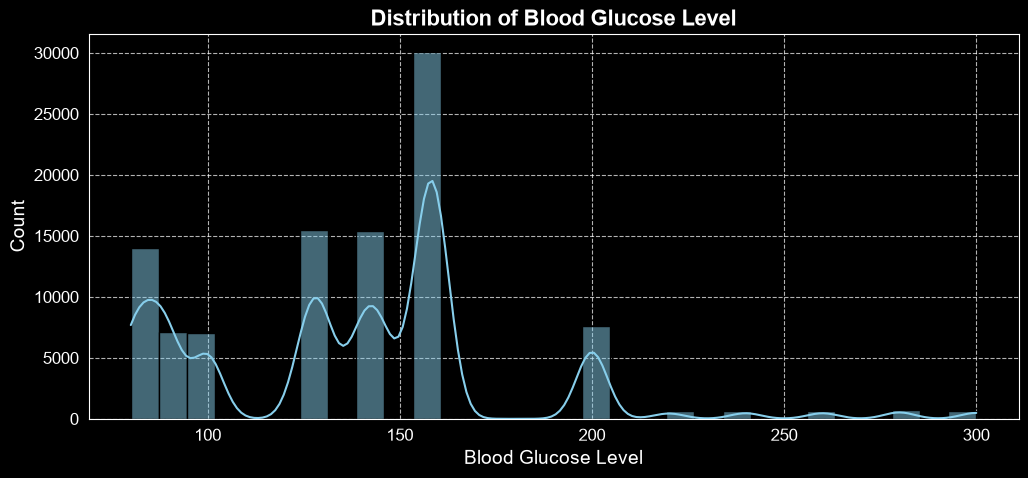

In [99]:
plt.figure(figsize=(12, 5), dpi=100)

ax = sns.histplot(data=df, x="blood_glucose_level", kde=True, bins=30, color='skyblue', edgecolor='black')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("Blood Glucose Level", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.title("Distribution of Blood Glucose Level", fontsize=16, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

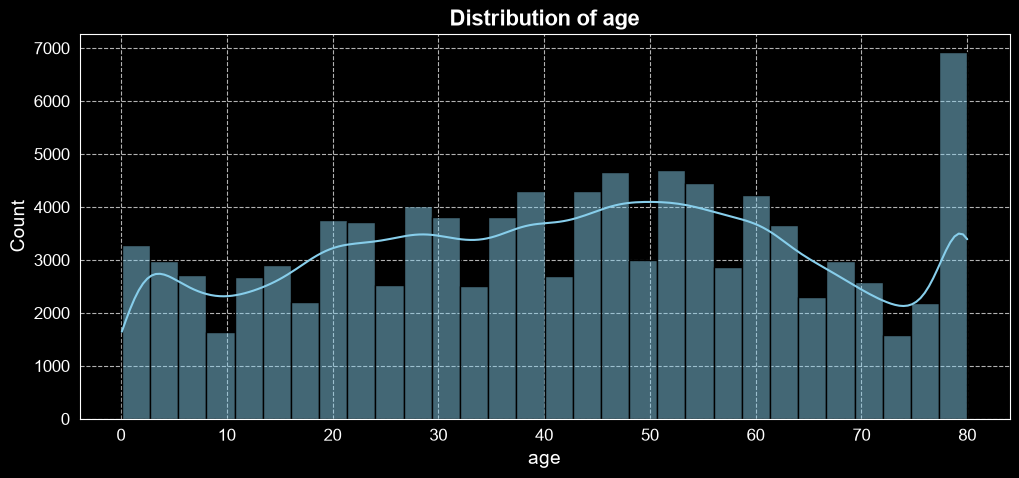

In [100]:
plt.figure(figsize=(12, 5), dpi=100)

ax = sns.histplot(data=df, x="age", kde=True, bins=30, color='skyblue', edgecolor='black')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("age", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.title("Distribution of age", fontsize=16, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [101]:
(df['age'] < 1).sum()

np.int64(911)

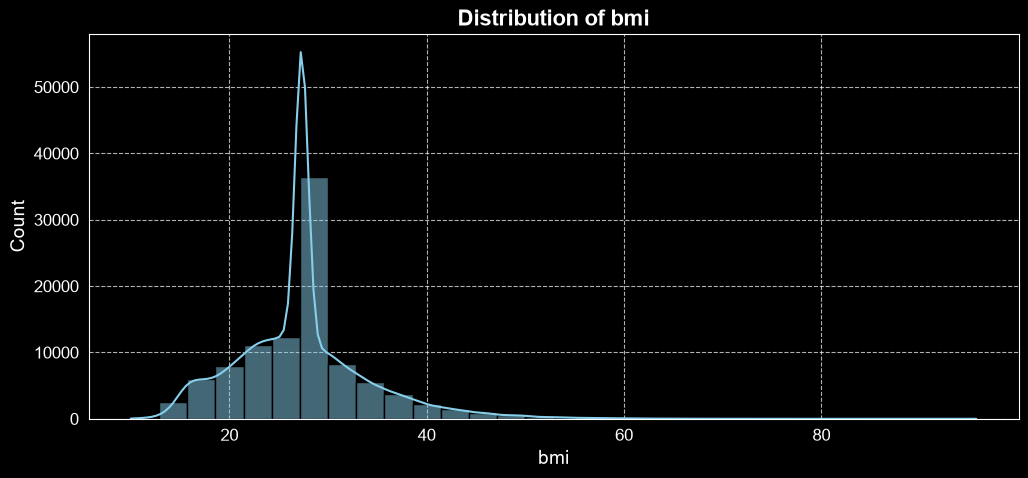

In [102]:
plt.figure(figsize=(12, 5), dpi=100)

ax = sns.histplot(data=df, x="bmi", kde=True, bins=30, color='skyblue', edgecolor='black')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("bmi", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.title("Distribution of bmi", fontsize=16, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

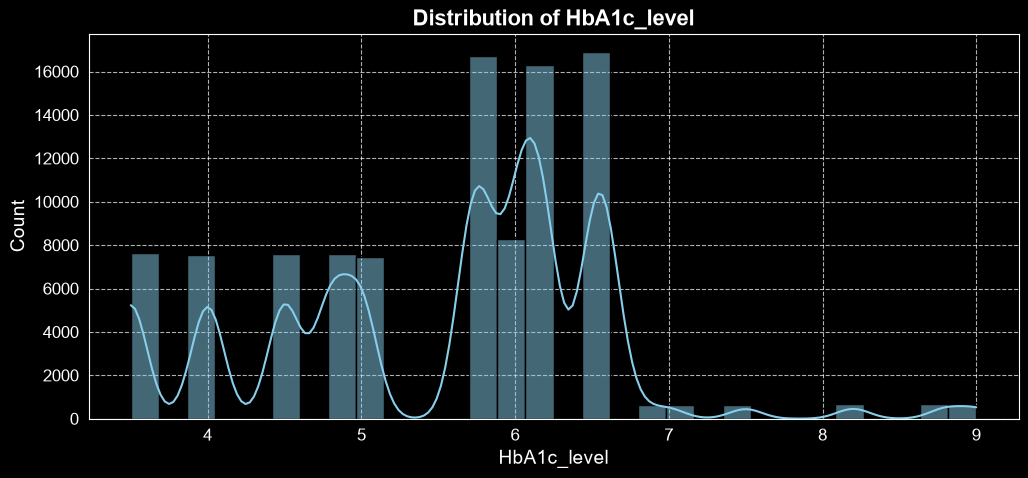

In [103]:
plt.figure(figsize=(12, 5), dpi=100)

ax = sns.histplot(data=df, x="HbA1c_level", kde=True, bins=30, color='skyblue', edgecolor='black')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("HbA1c_level", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.title("Distribution of HbA1c_level", fontsize=16, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

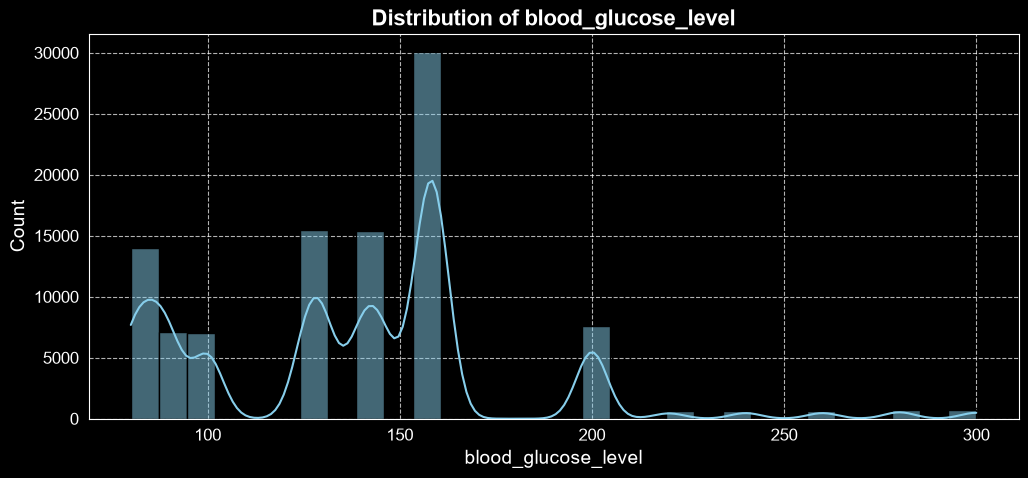

In [104]:
plt.figure(figsize=(12, 5), dpi=100)

ax = sns.histplot(data=df, x="blood_glucose_level", kde=True, bins=30, color='skyblue', edgecolor='black')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("blood_glucose_level", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.title("Distribution of blood_glucose_level", fontsize=16, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

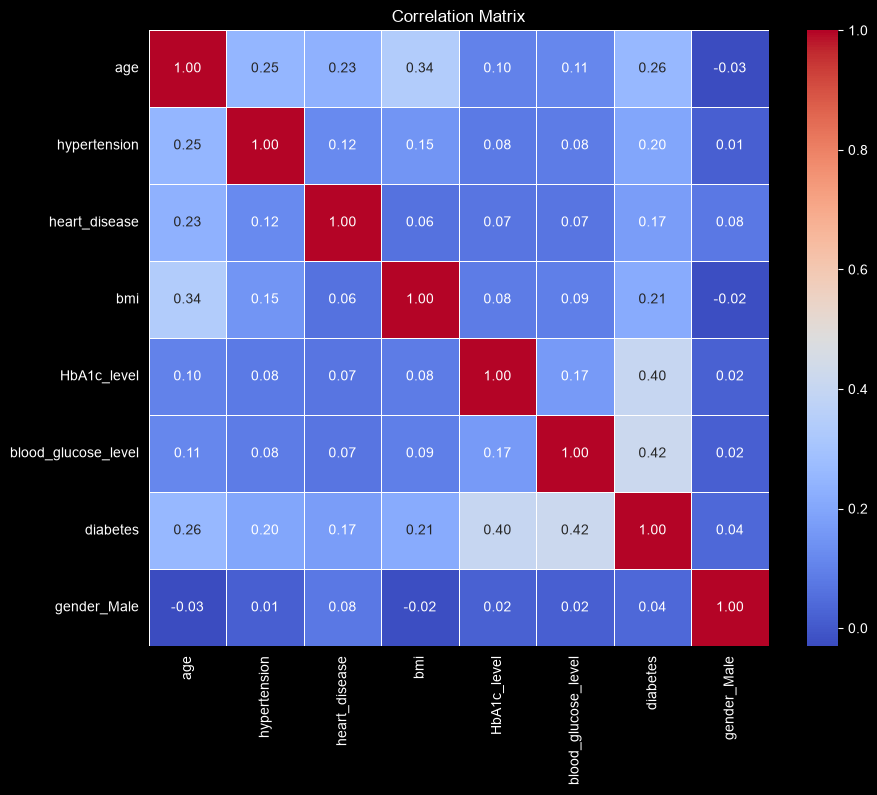

In [105]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

In [106]:
df.to_csv("../data/processed_data.csv", index=False)